# Concentric Reactor 2D Diffusion Model from OpenMC MGXS

This notebook is a diffusion-specific consumer of resolved OpenMC MGXS exports. It does not build transport libraries or homogenize the complete fuel element into a single region.

## Workflow
- Select one resolved `group_sweep/group_<N>` export.
- Load and validate the export through `backend.reactor_backend.openmc_mgxs_adapter`.
- Preserve each OpenMC cell domain as a separate diffusion region.
- Use OpenMC's exported transport-based diffusion coefficient, `D = 1 / (3 Sigma_tr)`.
- Use only the non-`nu` P0 scattering matrix and reject exports whose P0 diagonal was transport-corrected.
- Solve the clean core and compare with the OpenMC eigenvalue as context, not as a pre-SPH calibration target.

SPH and discontinuity-factor corrections are intentionally deferred until this uncorrected diffusion workflow is stable and reproducible. The rod scan at the end remains an exploratory equivalent-absorber study.

In [1]:
import importlib
from pathlib import Path
from pprint import pprint
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent
if not (project_root / "backend").is_dir():
    project_root = Path.cwd()
sys.path.insert(0, str(project_root))

import backend.reactor_backend.diffusion
import backend.reactor_backend.multigroup_diffusion
import backend.reactor_backend.openmc_mgxs_adapter

importlib.reload(backend.reactor_backend.diffusion)
importlib.reload(backend.reactor_backend.multigroup_diffusion)
importlib.reload(backend.reactor_backend.openmc_mgxs_adapter)

from backend.reactor_backend.diffusion import rho_pcm
from backend.reactor_backend.multigroup_diffusion import (
    build_multigroup_2d_matrices,
    scan_multigroup_rod_worth_2d,
    solve_multigroup_2d,
)
from backend.reactor_backend.openmc_mgxs_adapter import (
    load_concentric_diffusion_input,
)

matplotlib.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.35})
print("Imports OK - numpy", np.__version__, "matplotlib", matplotlib.__version__)

Imports OK - numpy 2.4.6 matplotlib 3.10.9


## 1. Select and Validate a Resolved MGXS Export

`MGXS_EXPORT_DIR` is the only OpenMC input selected in this notebook. The adapter reads both `reactor_run/model.xml` and `outputs/mgxs_constants.json` from that directory.

The export must contain resolved fuel-ring domains and must explicitly declare `scatter_correction = null`. Higher-order Legendre exports are accepted, but only their zeroth moment is passed to diffusion.

In [2]:
MGXS_EXPORT_DIR = (
    project_root
    / "openmc"
    / "build"
    / "concentric"
    / "mgxs_export"
    / "group_sweep"
    / "group_1"
)

DIFFUSION_INPUT = load_concentric_diffusion_input(MGXS_EXPORT_DIR)
INPUT_SUMMARY = DIFFUSION_INPUT.summary()

print("=== OPENMC MGXS DIFFUSION INPUT ===")
print(f"Export directory          = {DIFFUSION_INPUT.export_dir}")
print(f"Energy groups             = {DIFFUSION_INPUT.group_count}")
print(f"Source scattering order   = P{DIFFUSION_INPUT.source_legendre_order}")
print("Diffusion scattering      = P0 non-nu")
print(f"Higher moments discarded  = {INPUT_SUMMARY['discarded_higher_moments']}")
print(f"Scatter correction        = {INPUT_SUMMARY['scatter_correction']}")
print(f"Scatter matrix source(s)  = {INPUT_SUMMARY['validation']['scatter_matrix_sources']}")
print(f"Resolved zones            = {INPUT_SUMMARY['zone_count']}")
print(
    "Max D consistency error   = "
    f"{INPUT_SUMMARY['validation']['max_diffusion_relative_error']:.3e}"
)
print(
    "Domains with sanitized D = "
    f"{INPUT_SUMMARY['validation']['sanitized_domain_count']}"
)

sanitized = {
    label: data["diffusion_replacements"]
    for label, data in INPUT_SUMMARY["validation"]["domains"].items()
    if data["diffusion_replacements"]
}
if sanitized:
    print("\nInactive-group diffusion replacements")
    pprint(sanitized, sort_dicts=False)

=== OPENMC MGXS DIFFUSION INPUT ===
Export directory          = /home/pablo/modelica/ReactorKineticsLab/openmc/build/concentric/mgxs_export/group_sweep/group_1
Energy groups             = 1
Source scattering order   = P0
Diffusion scattering      = P0 non-nu
Higher moments discarded  = False
Scatter correction        = None
Scatter matrix source(s)  = ['consistent scatter matrix']
Resolved zones            = 12
Max D consistency error   = 1.380e-16
Domains with sanitized D = 0


## 2. Build the Resolved 2D Diffusion Model

The zone map comes from the OpenMC XML and MGXS domain mapping. Fuel rings, central channel, coolant/moderator, outer moderator, reflector, and parked rod retain separate region constants.

The equivalent rod absorption below is not used in the clean solve. It is retained only for the exploratory scan in Section 5.

In [3]:
DELTA_SIGMA_A_ROD = 0.25
DR_CM = 0.5
DZ_CM = 10.0

model_2d = DIFFUSION_INPUT.build_model(
    delta_absorption_rod=DELTA_SIGMA_A_ROD,
)
operator_matrix, _, mesh_r, mesh_z, nr, nz, group_count = build_multigroup_2d_matrices(
    model_2d,
    DR_CM,
    DZ_CM,
    x_insert=0.0,
)

fuel_zone_cell_counts = {}
for zone in DIFFUSION_INPUT.zone_report:
    if zone['label'] not in DIFFUSION_INPUT.fuel_ring_labels:
        continue
    radial_cells = np.count_nonzero(
        (mesh_r >= zone['r_min_cm']) & (mesh_r < zone['r_max_cm'])
    )
    axial_cells = np.count_nonzero(
        (mesh_z >= zone['z_min_cm']) & (mesh_z < zone['z_max_cm'])
    )
    fuel_zone_cell_counts[zone['label']] = int(radial_cells * axial_cells)
unresolved_fuel_zones = [
    label for label, count in fuel_zone_cell_counts.items() if count == 0
]
if unresolved_fuel_zones:
    raise RuntimeError(
        'Diffusion mesh does not resolve fuel zones: '
        + ', '.join(unresolved_fuel_zones)
    )

geometry = DIFFUSION_INPUT.geometry
print("=== RESOLVED CONCENTRIC DIFFUSION MODEL ===")
print(f"Energy groups            = {group_count}")
print(f"Core radius              = {geometry['core_radius_cm']:.1f} cm")
print(f"Fuel envelope height     = {geometry['fuel_element_height_cm']:.1f} cm")
print(f"Active fuel height       = {geometry['core_height_cm']:.1f} cm")
print(f"Moderator outer radius   = {geometry['moderator_radius_cm']:.1f} cm")
print(f"Reflector outer radius   = {geometry['reflector_radius_cm']:.1f} cm")
print(f"Mesh                     = {nr} x {nz} = {nr*nz:,} cells")
print(f"Sparse matrix nonzeros   = {operator_matrix.nnz:,}")
print(f"Minimum cells/fuel ring  = {min(fuel_zone_cell_counts.values())}")

print("\nResolved zones")
for zone in DIFFUSION_INPUT.zone_report:
    print(
        f"{zone['label']:>42}: "
        f"r=[{zone['r_min_cm']:.1f}, {zone['r_max_cm']:.1f}) cm, "
        f"z=[{zone['z_min_cm']:.1f}, {zone['z_max_cm']:.1f}) cm"
    )

=== RESOLVED CONCENTRIC DIFFUSION MODEL ===
Energy groups            = 1
Core radius              = 50.0 cm
Fuel envelope height     = 400.0 cm
Active fuel height       = 300.0 cm
Moderator outer radius   = 250.0 cm
Reflector outer radius   = 500.0 cm
Mesh                     = 1001 x 100 = 100,100 cells
Sparse matrix nonzeros   = 498,298
Minimum cells/fuel ring  = 30

Resolved zones
                                 reflector: r=[0.0, 500.0) cm, z=[-500.0, 500.0) cm
                                 moderator: r=[0.0, 250.0) cm, z=[-300.0, 300.0) cm
    core_heavy_water_coolant_and_moderator: r=[0.0, 50.0) cm, z=[-200.0, 200.0) cm
            core_central_moderator_channel: r=[0.0, 4.0) cm, z=[-200.0, 150.0) cm
                          core_fuel_ring_1: r=[4.5, 5.0) cm, z=[-150.0, 150.0) cm
                          core_fuel_ring_2: r=[12.0, 12.5) cm, z=[-150.0, 150.0) cm
                          core_fuel_ring_3: r=[19.5, 20.0) cm, z=[-150.0, 150.0) cm
                          core

## 3. Clean-Core Stability Solve

This unrodded solve is the primary result. The stability milestone is a finite, positive, reproducible eigenvalue and physically coherent flux shape. Agreement with OpenMC is reported to quantify the uncorrected diffusion bias; tight agreement is not required before the later SPH study.

In [4]:
MAX_ITER = 400
SOLVER_TOL = 1.0e-5

sol_clean = solve_multigroup_2d(
    model_2d,
    dr=DR_CM,
    dz=DZ_CM,
    x_insert=0.0,
    max_iter=MAX_ITER,
    tol=SOLVER_TOL,
)
k_diff = sol_clean["k_eff"]
rho_diff_pcm = rho_pcm(k_diff)
openmc_reference = DIFFUSION_INPUT.openmc_reference

if not np.isfinite(k_diff) or k_diff <= 0.0:
    raise RuntimeError(f"Diffusion solve returned invalid k_eff={k_diff}")
if sol_clean["iterations"] >= MAX_ITER:
    raise RuntimeError("Diffusion solve reached the iteration limit")

print("=== CLEAN CONCENTRIC GEOMETRY ===")
print(f"Energy groups           = {sol_clean['group_count']}")
print(f"Diffusion k_eff         = {k_diff:.6f}")
print(f"Diffusion reactivity    = {rho_diff_pcm:+.1f} pcm")
print(f"OpenMC k_eff            = {openmc_reference['keff']:.6f}")
print(f"OpenMC reactivity       = {openmc_reference['reactivity_pcm']:+.1f} pcm")
print(f"Delta k                 = {k_diff - openmc_reference['keff']:+.6f}")
print(f"Power iteration count   = {sol_clean['iterations']}")

=== CLEAN CONCENTRIC GEOMETRY ===
Energy groups           = 1
Diffusion k_eff         = 1.019056
Diffusion reactivity    = +1870.0 pcm
OpenMC k_eff            = 1.001090
OpenMC reactivity       = +108.9 pcm
Delta k                 = +0.017966
Power iteration count   = 35


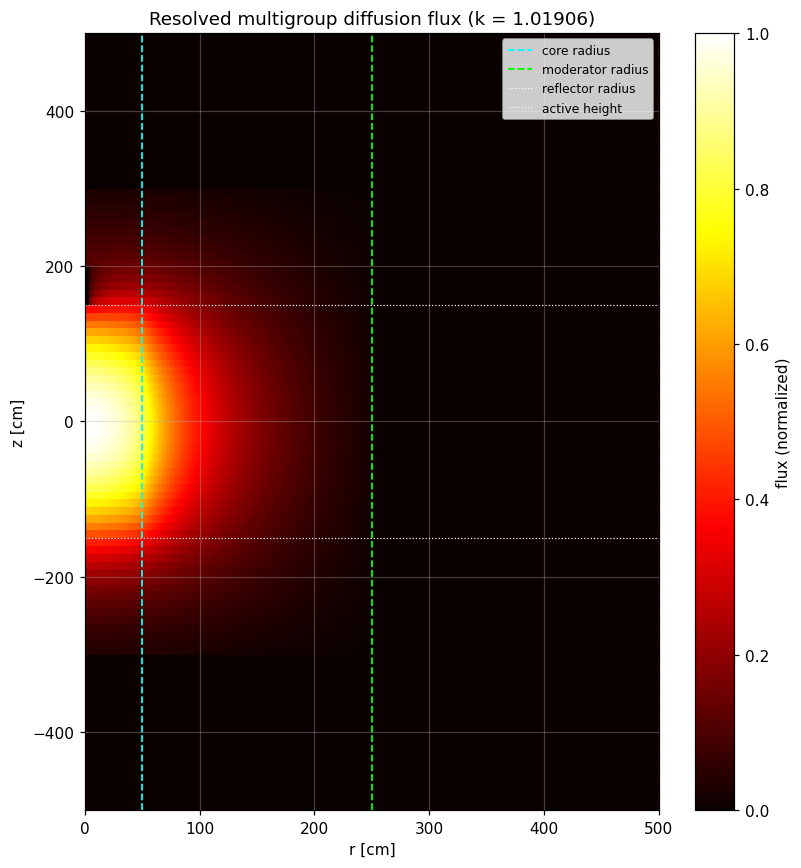

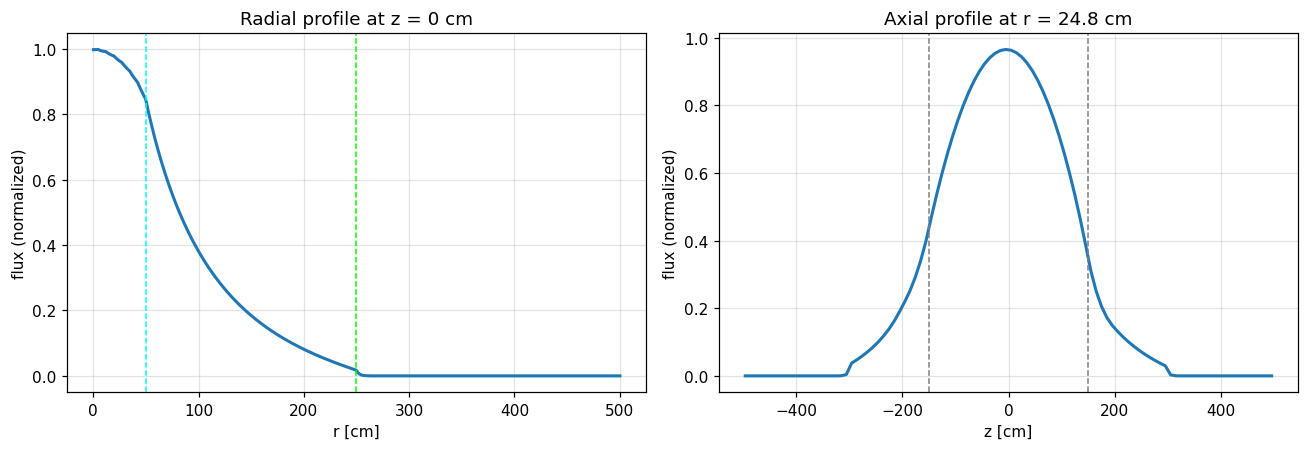

In [5]:
phi_clean = sol_clean["phi"]
r_grid = sol_clean["r_grid"]
z_grid = sol_clean["z_grid"]

fig, ax = plt.subplots(figsize=(7.5, 8.0))
image = ax.pcolormesh(r_grid, z_grid, phi_clean.T, cmap="hot", shading="auto")
ax.axvline(geometry["core_radius_cm"], color="cyan", lw=1.2, ls="--", label="core radius")
ax.axvline(geometry["moderator_radius_cm"], color="lime", lw=1.2, ls="--", label="moderator radius")
ax.axvline(geometry["reflector_radius_cm"], color="white", lw=0.8, ls=":", label="reflector radius")
ax.axhline(model_2d.core_height / 2, color="white", lw=0.8, ls=":", label="active height")
ax.axhline(-model_2d.core_height / 2, color="white", lw=0.8, ls=":")
plt.colorbar(image, ax=ax, label="flux (normalized)")
ax.set_xlabel("r [cm]")
ax.set_ylabel("z [cm]")
ax.set_title(f"Resolved multigroup diffusion flux (k = {k_diff:.5f})")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

midplane_index = int(np.argmin(np.abs(z_grid)))
axial_probe_radius_cm = 0.5 * geometry["core_radius_cm"]
axial_index = int(np.argmin(np.abs(r_grid - axial_probe_radius_cm)))

fig, (ax_r, ax_z) = plt.subplots(1, 2, figsize=(12, 4.2))
ax_r.plot(r_grid, phi_clean[:, midplane_index], lw=2)
ax_r.axvline(geometry["core_radius_cm"], color="cyan", lw=1.0, ls="--")
ax_r.axvline(geometry["moderator_radius_cm"], color="lime", lw=1.0, ls="--")
ax_r.set_xlabel("r [cm]")
ax_r.set_ylabel("flux (normalized)")
ax_r.set_title("Radial profile at z = 0 cm")

ax_z.plot(z_grid, phi_clean[axial_index, :], lw=2)
ax_z.axvline(model_2d.core_height / 2, color="gray", lw=1.0, ls="--")
ax_z.axvline(-model_2d.core_height / 2, color="gray", lw=1.0, ls="--")
ax_z.set_xlabel("z [cm]")
ax_z.set_ylabel("flux (normalized)")
ax_z.set_title(f"Axial profile at r = {r_grid[axial_index]:.1f} cm")

plt.tight_layout()
plt.show()

## 4. Exploratory Equivalent Rod Scan

This section is not part of the clean-core validation milestone. It adds a scalar absorption increment inside the physical rod radius as the rod enters the active height. It does not use rodded MGXS and is not a transport-calibrated rod-worth prediction.

In [ ]:
scan = scan_multigroup_rod_worth_2d(
    model_2d,
    x_values=np.linspace(0.0, 1.0, 11),
    dr=DR_CM,
    dz=DZ_CM,
    max_iter=MAX_ITER,
    tol=SOLVER_TOL,
    warm_start=True,
)

x_insert = scan["x_insert"]
delta_rho_pcm = scan["delta_rho_pcm"]
total_rho_pcm = scan["rho_total_pcm"]
if not np.isclose(scan["k_eff"][0], k_diff, rtol=0.0, atol=5.0e-6):
    raise RuntimeError("Rod scan and clean solve do not share a consistent zero-insertion state")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.5))
ax1.plot(x_insert * 100, delta_rho_pcm, "o-", lw=2, ms=5, label="equivalent rod worth")
ax1.plot(x_insert * 100, total_rho_pcm, "s--", lw=1.5, ms=4, label="total reactivity")
ax1.axhline(0.0, color="black", lw=0.6)
ax1.set_xlabel("Rod insertion [%]")
ax1.set_ylabel("Reactivity [pcm]")
ax1.set_title("Exploratory integral rod worth")
ax1.legend(loc="best")

differential_worth = np.gradient(delta_rho_pcm, x_insert)
ax2.plot(x_insert * 100, differential_worth, "o-", lw=2, ms=5)
ax2.axhline(0.0, color="black", lw=0.6)
ax2.set_xlabel("Rod insertion [%]")
ax2.set_ylabel("dDelta-rho/dx [pcm per unit insertion]")
ax2.set_title("Exploratory differential rod worth")
plt.tight_layout()
plt.show()

critical_insertion = scan["critical_insertion_fraction"]
print("=== EXPLORATORY EQUIVALENT ROD SCAN ===")
print("Not transport-calibrated; excluded from the stability acceptance criteria.")
print(f"Clean-core reactivity       = {scan['rho_clean_pcm']:+.1f} pcm")
print(f"Full-insertion rod worth    = {delta_rho_pcm[-1]:+.1f} pcm")
print(f"Full-insertion total rho    = {total_rho_pcm[-1]:+.1f} pcm")
if critical_insertion is None:
    print("Critical insertion          = not crossed in this scan")
else:
    print(f"Critical insertion          = {critical_insertion*100:.1f} %")

## 5. Interpretation and Next Milestone

This workflow now has one explicit responsibility: solve multigroup diffusion on the resolved OpenMC cell geometry using transport-based diffusion coefficients and an uncorrected non-`nu` P0 scattering matrix.

Before adding SPH factors, compare group-count and mesh-refinement trends, confirm deterministic convergence, and identify whether remaining bias comes from diffusion theory, boundary treatment, energy condensation, or cell-wise flux homogenization. SPH and discontinuity factors should only be introduced after those baseline behaviors are documented.